In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional settings
plt.rcParams['figure.figsize'] = (12,6)
sns.set_style("darkgrid")

In [3]:
df = pd.read_csv("/content/netflix_titles.csv")

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [7]:
df.drop_duplicates(inplace=True)

print("Duplicates Removed Successfully")

Duplicates Removed Successfully


In [8]:
df['director'].fillna('Unknown', inplace=True)

df['cast'].fillna('Not Available', inplace=True)

df['country'].fillna('Unknown', inplace=True)

df['rating'].fillna(df['rating'].mode()[0], inplace=True)

/tmp/ipykernel_1747/1853813862.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
/tmp/ipykernel_1747/1853813862.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [10]:
# Remove extra spaces first

df['date_added'] = df['date_added'].str.strip()

# Convert into datetime

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Check dataset

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [11]:
df.describe()

,date_added,release_year
count,8797,8807.000000
mean,2019-05-17 05:59:08.436967168,2014.180198
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-02 00:00:00,2017.000000
75%,2020-08-19 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.819312


In [12]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


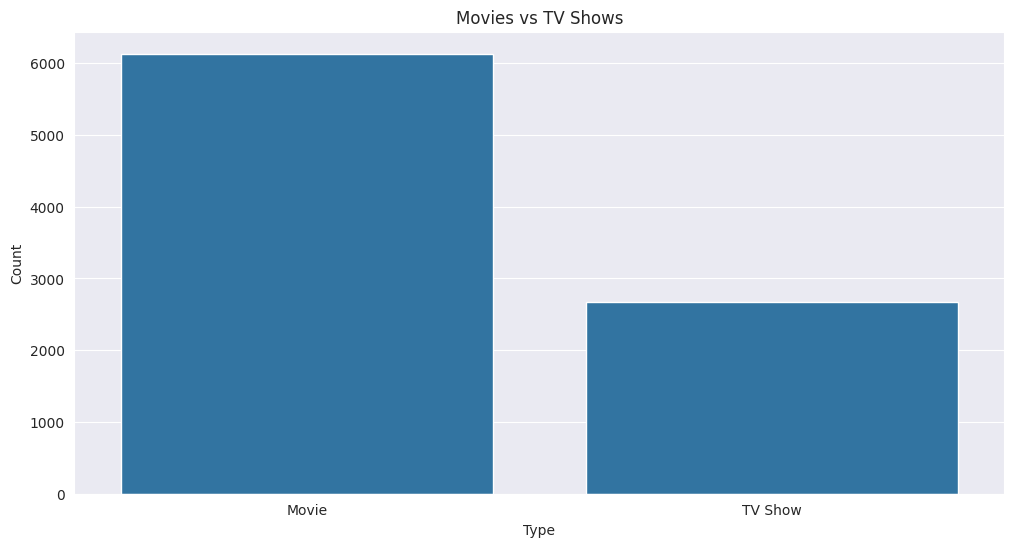

In [13]:
sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows")

plt.xlabel("Type")

plt.ylabel("Count")

plt.show()

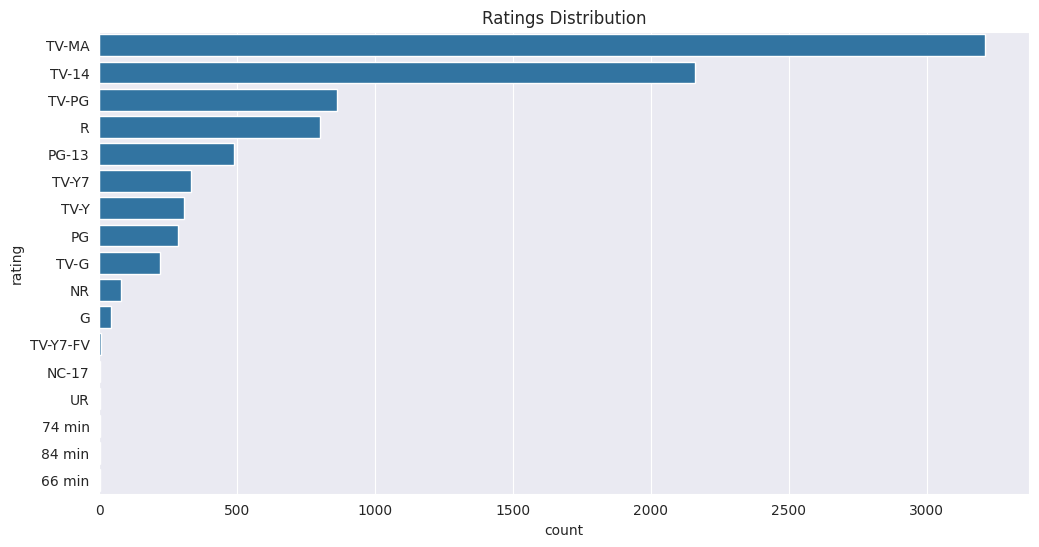

In [14]:
plt.figure(figsize=(12,6))

sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)

plt.title("Ratings Distribution")

plt.show()

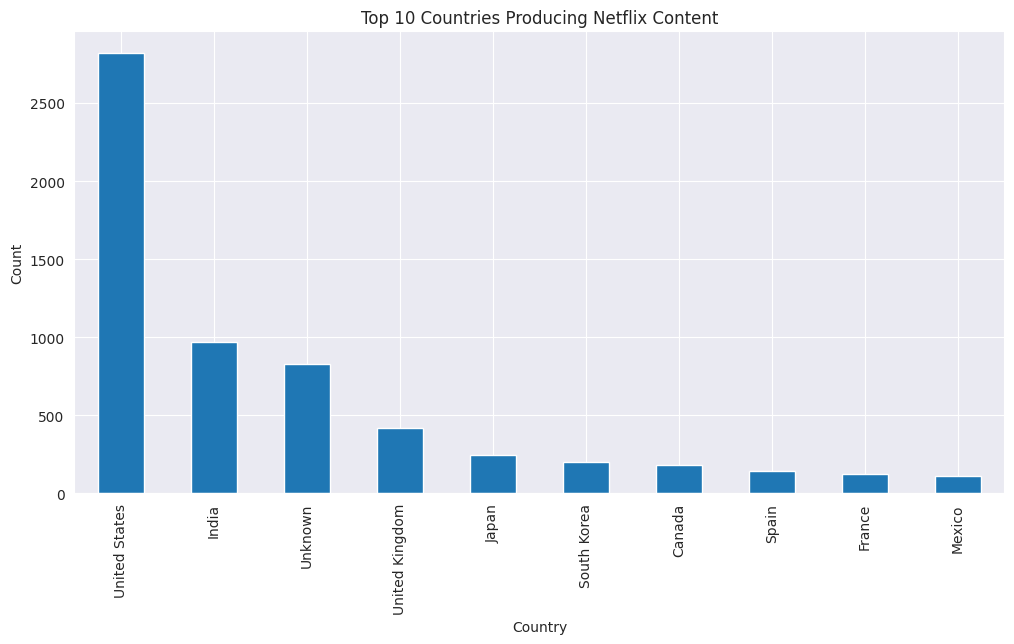

In [15]:
top_country = df['country'].value_counts().head(10)

top_country.plot(kind='bar')

plt.title("Top 10 Countries Producing Netflix Content")

plt.xlabel("Country")

plt.ylabel("Count")

plt.show()

In [16]:
df['year_added'] = df['date_added'].dt.year

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


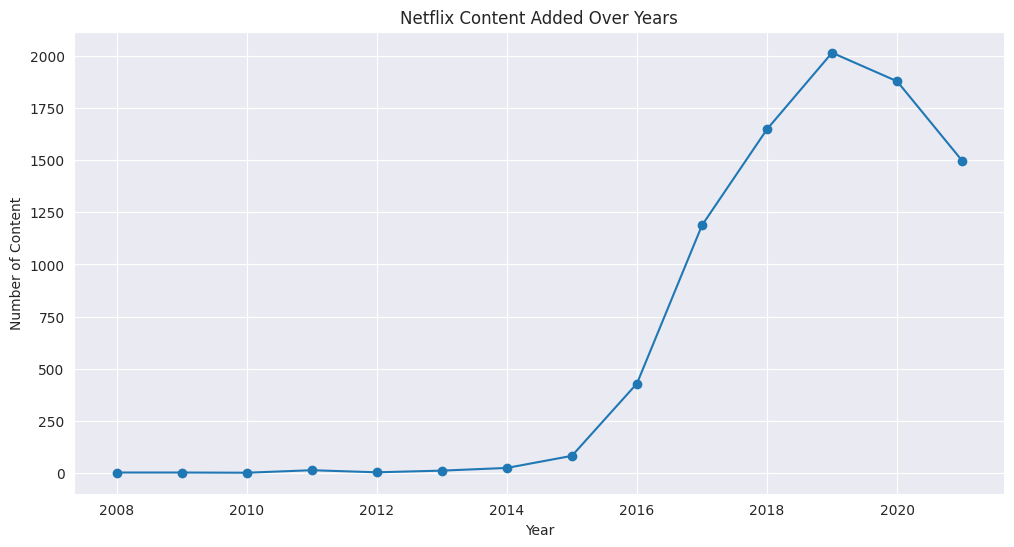

In [17]:
df['year_added'].value_counts().sort_index().plot(kind='line', marker='o')

plt.title("Netflix Content Added Over Years")

plt.xlabel("Year")

plt.ylabel("Number of Content")

plt.show()

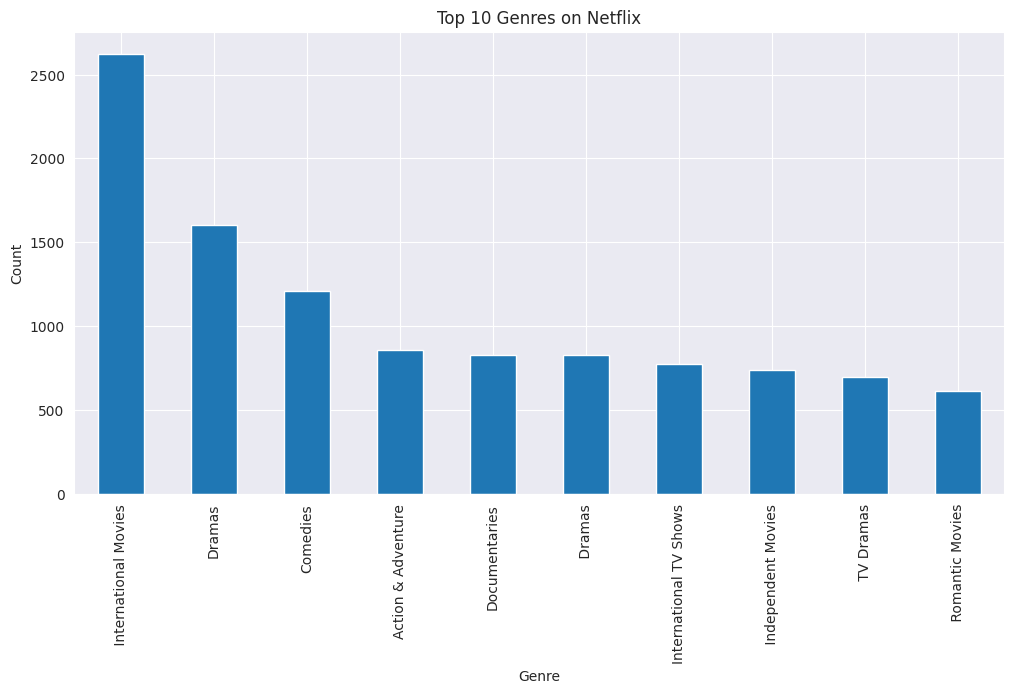

In [18]:
genres = df['listed_in'].str.split(',', expand=True).stack()

top_genres = genres.value_counts().head(10)

top_genres.plot(kind='bar')

plt.title("Top 10 Genres on Netflix")

plt.xlabel("Genre")

plt.ylabel("Count")

plt.show()

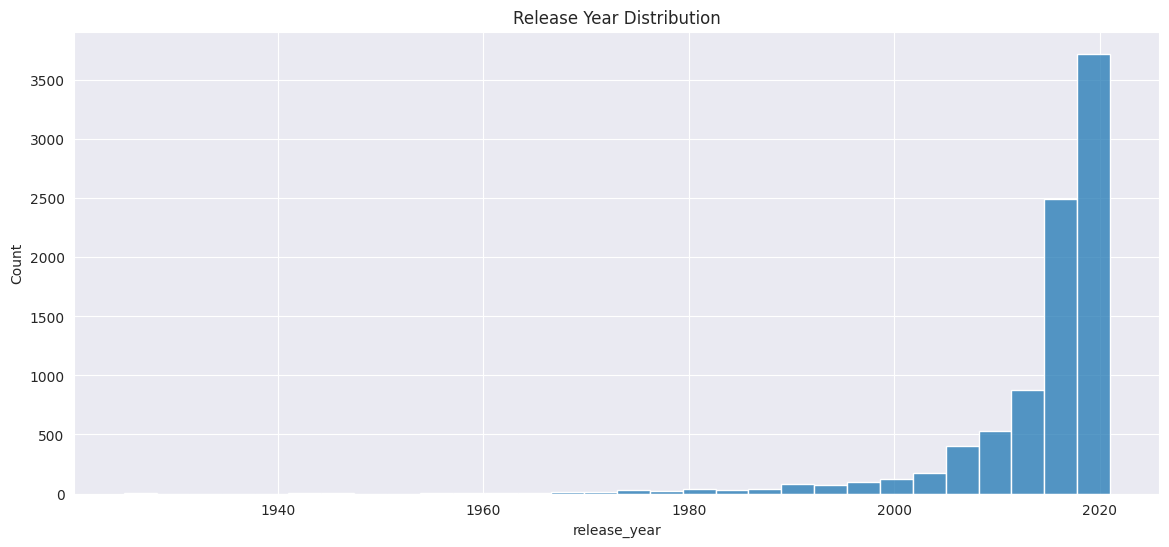

In [19]:
plt.figure(figsize=(14,6))

sns.histplot(df['release_year'], bins=30)

plt.title("Release Year Distribution")

plt.show()

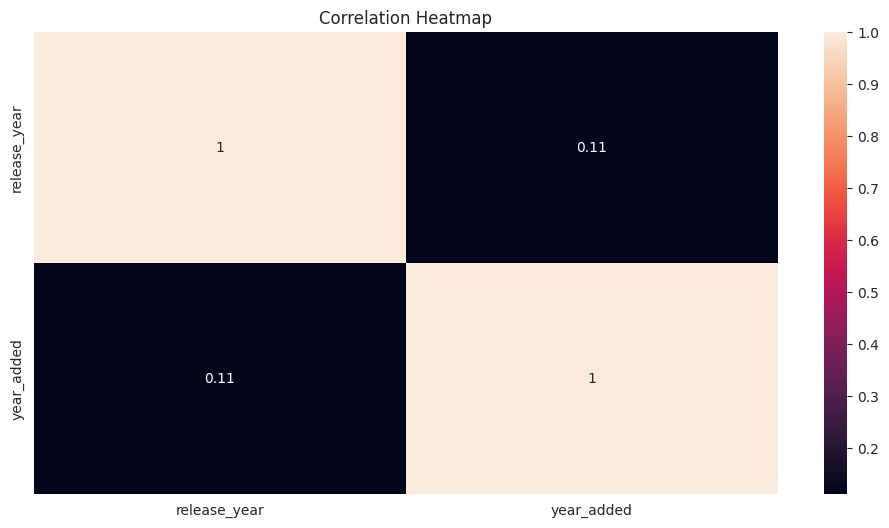

In [20]:
numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Heatmap")

plt.show()

In [21]:
df['rating'].value_counts().head(10)

,count
rating,
TV-MA,3211
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


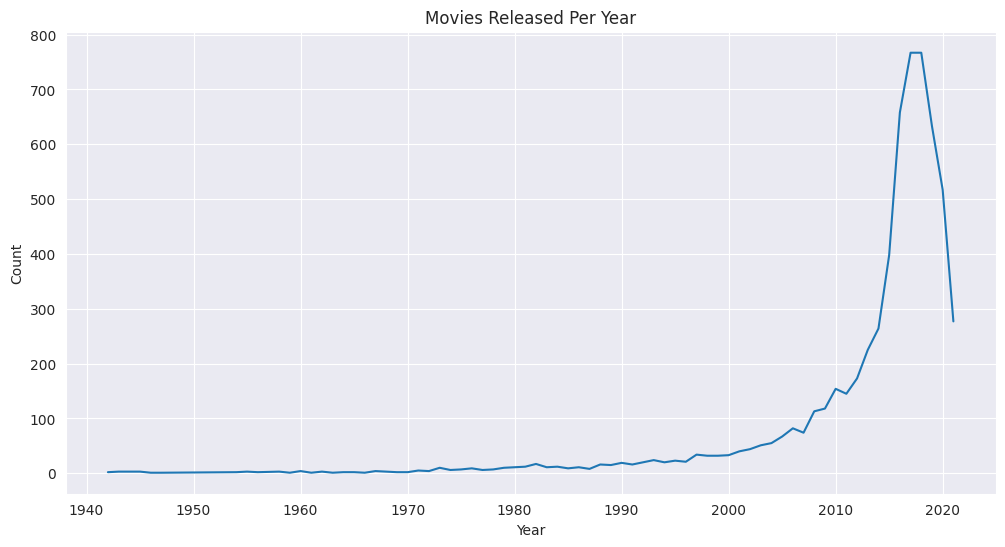

In [22]:
movies = df[df['type'] == 'Movie']

movies['release_year'].value_counts().sort_index().plot(kind='line')

plt.title("Movies Released Per Year")

plt.xlabel("Year")

plt.ylabel("Count")

plt.show()

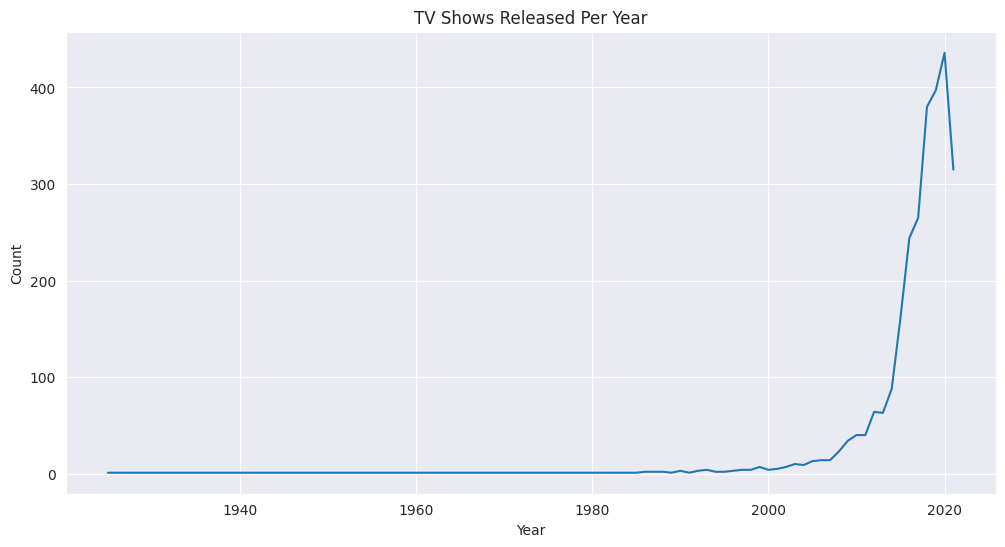

In [23]:
tvshows = df[df['type'] == 'TV Show']

tvshows['release_year'].value_counts().sort_index().plot(kind='line')

plt.title("TV Shows Released Per Year")

plt.xlabel("Year")

plt.ylabel("Count")

plt.show()

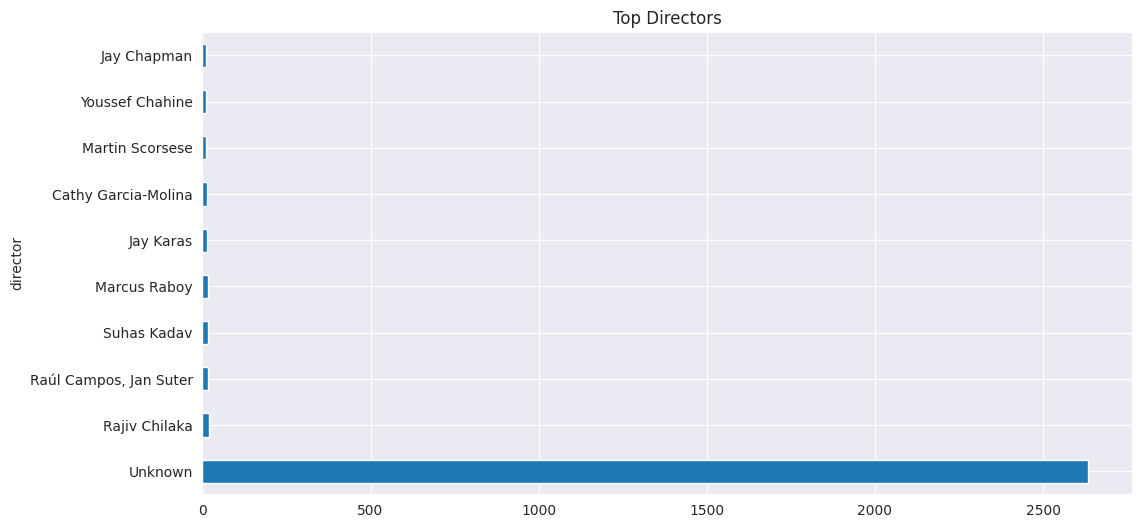

In [24]:
top_directors = df['director'].value_counts().head(10)

top_directors.plot(kind='barh')

plt.title("Top Directors")

plt.show()

In [25]:
df.to_csv("cleaned_netflix_dataset.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [26]:
print("1. Movies are more than TV Shows.")

print("2. USA produces highest Netflix content.")

print("3. Drama and Comedy are popular genres.")

print("4. Netflix growth increased after 2015.")

print("5. TV-MA is the most common rating.")

1. Movies are more than TV Shows.
2. USA produces highest Netflix content.
3. Drama and Comedy are popular genres.
4. Netflix growth increased after 2015.
5. TV-MA is the most common rating.
